# CA05 - Bernardo Frederick Kowe - 0706022310049

In [262]:
# import library
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import tree
from google.colab import drive

In [263]:
# Mount Google Drive
drive.mount('/content/drive')

# Path ke file CSV di Google Drive
path = '/content/drive/MyDrive/Data Mining/W05/exercise_employee_attrition.txt'

# Baca file CSV
df = pd.read_csv(path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [264]:
# get info from dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

In [265]:
# get statistical info from dataset
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.991000,3.055000,11499.899000,57.837000,14.922000,7.539000,4.40800,2.495000,3.151000,2.52700,50.043000,4.877000,44.553000,9.524000,2.494000,2.519000,2.503000,24.507000,2.484000
std,288.819436,11.780055,1.399977,4920.529231,24.702037,8.350548,4.001061,2.99508,1.105077,1.426967,1.13073,28.204657,2.546833,8.704192,5.973534,1.110494,1.106736,1.099636,14.138099,1.111296
min,1.000000,20.000000,1.000000,3001.000000,15.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.00000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,250.750000,30.000000,2.000000,7395.750000,36.000000,8.000000,4.000000,2.00000,2.000000,2.000000,2.00000,26.000000,3.000000,37.000000,4.000000,2.000000,2.000000,2.000000,12.000000,1.000000
50%,500.500000,41.000000,3.000000,11256.000000,58.000000,15.000000,8.000000,4.00000,3.000000,3.000000,3.00000,50.000000,5.000000,45.000000,9.000000,2.000000,3.000000,3.000000,24.000000,2.000000
75%,750.250000,50.250000,4.000000,15855.000000,80.000000,22.000000,11.000000,7.00000,3.000000,4.000000,4.00000,75.250000,7.000000,52.000000,15.000000,4.000000,4.000000,3.000000,37.000000,3.000000
max,1000.000000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.00000,4.000000,5.000000,4.00000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


# Preprocessing

In [266]:
# show unique values from dataset
unique_values = {col: df[col].unique() for col in df.columns}
display(unique_values)

{'Employee_ID': array([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,   11,
          12,   13,   14,   15,   16,   17,   18,   19,   20,   21,   22,
          23,   24,   25,   26,   27,   28,   29,   30,   31,   32,   33,
          34,   35,   36,   37,   38,   39,   40,   41,   42,   43,   44,
          45,   46,   47,   48,   49,   50,   51,   52,   53,   54,   55,
          56,   57,   58,   59,   60,   61,   62,   63,   64,   65,   66,
          67,   68,   69,   70,   71,   72,   73,   74,   75,   76,   77,
          78,   79,   80,   81,   82,   83,   84,   85,   86,   87,   88,
          89,   90,   91,   92,   93,   94,   95,   96,   97,   98,   99,
         100,  101,  102,  103,  104,  105,  106,  107,  108,  109,  110,
         111,  112,  113,  114,  115,  116,  117,  118,  119,  120,  121,
         122,  123,  124,  125,  126,  127,  128,  129,  130,  131,  132,
         133,  134,  135,  136,  137,  138,  139,  140,  141,  142,  143,
         144,  145,  14

In [267]:
# Drop EmployeeCount as it has only 1 unique value.
# Drop EmployeeNumber as it's only an identifier.
# Drop Over18 because it's a constant value ('Y').
# Drop StandardHours because it's a constant value (80).

df = df.drop(columns=['Employee_ID'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Age                            1000 non-null   int64 
 1   Gender                         1000 non-null   object
 2   Marital_Status                 1000 non-null   object
 3   Department                     1000 non-null   object
 4   Job_Role                       1000 non-null   object
 5   Job_Level                      1000 non-null   int64 
 6   Monthly_Income                 1000 non-null   int64 
 7   Hourly_Rate                    1000 non-null   int64 
 8   Years_at_Company               1000 non-null   int64 
 9   Years_in_Current_Role          1000 non-null   int64 
 10  Years_Since_Last_Promotion     1000 non-null   int64 
 11  Work_Life_Balance              1000 non-null   int64 
 12  Job_Satisfaction               1000 non-null   int64 
 13  Perf

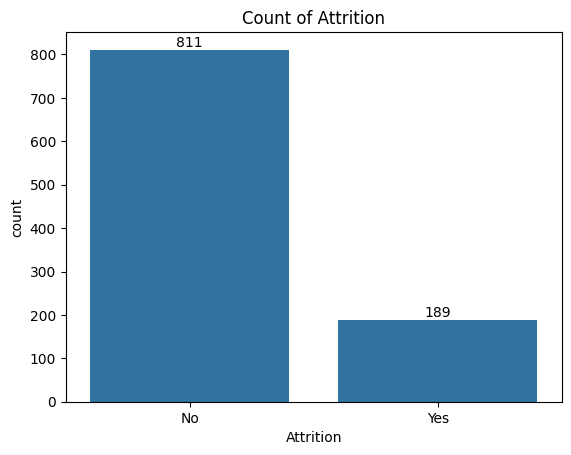

In [268]:
# show how many attrition
ax = sns.countplot(data=df, x='Attrition')
plt.title('Count of Attrition')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# imbalance dataset but it's okay let us try firsttt

# Feature Encoding

In [271]:
# Diasumsikan 'df' adalah DataFrame setelah menghapus Employee_ID
df_encoded = df.copy()

# --- 1. Label Encoding untuk Kolom Biner ---
# Ini untuk kolom yang hanya punya 2 pilihan (Yes/No, Male/Female).
# Metode .map() yang gunakan sudah sangat tepat untuk ini.

binary_cols_map = {
    'Attrition': {'No': 0, 'Yes': 1},
    'Gender': {'Female': 0, 'Male': 1},
    'Overtime': {'No': 0, 'Yes': 1} # Di dataset kita namanya 'Overtime'
}

for col, mapping in binary_cols_map.items():
    df_encoded[col] = df_encoded[col].map(mapping)

# 1. Mapping manual untuk 'Marital_Status'
marital_map = {'Married': 0, 'Divorced': 1, 'Single': 2}
df_encoded['Marital_Status'] = df_encoded['Marital_Status'].map(marital_map)

# 2. Mapping manual untuk 'Department'
department_map = {'IT': 0, 'Sales': 1, 'Marketing': 2, 'Finance': 3, 'HR': 4}
df_encoded['Department'] = df_encoded['Department'].map(department_map)

# 3. Mapping manual untuk 'Job_Role'
job_role_map = {'Manager': 0, 'Assistant': 1, 'Executive': 2, 'Analyst': 3}
df_encoded['Job_Role'] = df_encoded['Job_Role'].map(job_role_map)

# Tampilkan info untuk memastikan semua kolom sudah numerik
print("\nInfo DataFrame setelah encoding:")
df_encoded.info()


Info DataFrame setelah encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Age                            1000 non-null   int64
 1   Gender                         1000 non-null   int64
 2   Marital_Status                 1000 non-null   int64
 3   Department                     1000 non-null   int64
 4   Job_Role                       1000 non-null   int64
 5   Job_Level                      1000 non-null   int64
 6   Monthly_Income                 1000 non-null   int64
 7   Hourly_Rate                    1000 non-null   int64
 8   Years_at_Company               1000 non-null   int64
 9   Years_in_Current_Role          1000 non-null   int64
 10  Years_Since_Last_Promotion     1000 non-null   int64
 11  Work_Life_Balance              1000 non-null   int64
 12  Job_Satisfaction               1000 non-nul

In [272]:
df_encoded.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,58,0,0,0,0,1,15488,28,15,4,...,0,6,54,17,4,4,4,20,3,0
1,48,0,0,1,1,5,13079,28,6,9,...,1,2,45,1,4,1,2,25,2,0
2,34,1,0,2,1,1,13744,24,24,14,...,1,6,34,2,3,4,4,45,3,0
3,27,0,1,2,0,1,6809,26,10,8,...,0,9,48,18,2,3,1,35,3,0
4,40,1,1,2,2,1,10206,52,29,10,...,0,3,33,0,4,1,3,44,3,0


In [273]:
# checking encode result
df_encoded.loc[480]

,480
Age,31
Gender,0
Marital_Status,2
Department,2
Job_Role,0
Job_Level,5
Monthly_Income,4191
Hourly_Rate,63
Years_at_Company,18
Years_in_Current_Role,3


## Separate features and target

### Subtask:
Define the features (X) and the target variable (y).


**Reasoning**:
Define the features (X) by dropping the target variable 'Attrition' from the DataFrame and define the target variable (y) as the 'Attrition' column.



In [274]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

In [275]:
X.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
0,58,0,0,0,0,1,15488,28,15,4,...,14,0,6,54,17,4,4,4,20,3
1,48,0,0,1,1,5,13079,28,6,9,...,6,1,2,45,1,4,1,2,25,2
2,34,1,0,2,1,1,13744,24,24,14,...,77,1,6,34,2,3,4,4,45,3
3,27,0,1,2,0,1,6809,26,10,8,...,49,0,9,48,18,2,3,1,35,3
4,40,1,1,2,2,1,10206,52,29,10,...,64,0,3,33,0,4,1,3,44,3


In [276]:
y.head()

,Attrition
0,0
1,0
2,0
3,0
4,0


## Split data

### Subtask:
Split the encoded data into training and testing sets.


**Reasoning**:
Split the encoded feature DataFrame X and the target Series y into training and testing sets.



In [283]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=62)

In [284]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((800, 24), (200, 24))

In [285]:
X_train.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
275,49,0,1,1,0,3,14348,73,11,5,...,26,0,3,52,14,1,4,1,16,4
476,43,1,1,3,1,2,7476,90,10,11,...,67,0,1,59,14,4,2,2,9,4
735,37,1,2,2,2,5,18424,49,2,5,...,85,1,8,43,6,3,3,3,19,2
89,54,1,0,1,3,4,5575,39,10,8,...,83,0,4,34,6,2,2,4,1,4
176,42,0,0,3,2,3,17414,21,21,6,...,61,1,3,43,0,3,3,1,8,3


In [286]:
X_test.head()

,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,...,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
846,52,1,0,3,1,5,19075,39,23,1,...,76,1,9,57,0,1,4,3,39,4
536,38,1,1,3,2,3,8074,56,10,10,...,70,0,3,47,6,4,2,1,49,2
926,59,0,1,0,2,5,10367,68,1,9,...,99,1,4,43,11,1,4,2,10,3
538,20,1,0,1,3,4,10099,32,24,12,...,85,1,5,39,13,3,4,3,45,2
196,30,1,0,0,0,3,4211,82,7,4,...,18,1,3,58,3,2,2,2,40,3


# Decision Tree Classifier

In [287]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

tree = DecisionTreeClassifier(random_state=13)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       636
           1       1.00      1.00      1.00       164

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       175
           1       0.19      0.28      0.23        25

    accuracy                           0.77       200
   macro avg       0.54      0.56      0.55       200
weighted avg       0.80      0.77      0.78       200



# What to do next?
*   The F1 Score also significantly different so we need to handle this imbalance dataset. <br>
*   The accuracy of training set is 100% and testing set is 77%. This indicates overfitting, therefore we need to apply pre-prunning to the tree. We will tune the parameter by add a max_depth (limiting the depth/ branching of tree) and etc. <br>
*   And maybe we need to select and drop some features for the model.

# Oversampling using SMOTENC

In [288]:
# using SMOTE-NC for dataset containing numerical and categorical features.

from imblearn.over_sampling import SMOTENC

# we should define the categorical features first to make oversampling more accurate
categorical_features = [
    'Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime', # Nominal
    'Job_Level', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', # Ordinal
    'Work_Environment_Satisfaction', 'Relationship_with_Manager',
    'Job_Involvement'
]

smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X, y = smotenc.fit_resample(X, y)

# dont forget to always do partitioning AFTER undersampling/oversampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((1297, 24), (325, 24))

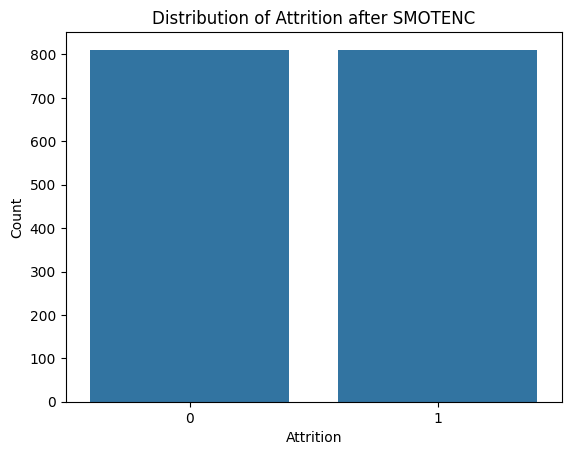

In [289]:
# just to visualize the distribution of target class after SMOTENC

sns.countplot(x=y)
plt.title('Distribution of Attrition after SMOTENC')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Age                            1000 non-null   int64 
 1   Gender                         1000 non-null   object
 2   Marital_Status                 1000 non-null   object
 3   Department                     1000 non-null   object
 4   Job_Role                       1000 non-null   object
 5   Job_Level                      1000 non-null   int64 
 6   Monthly_Income                 1000 non-null   int64 
 7   Hourly_Rate                    1000 non-null   int64 
 8   Years_at_Company               1000 non-null   int64 
 9   Years_in_Current_Role          1000 non-null   int64 
 10  Years_Since_Last_Promotion     1000 non-null   int64 
 11  Work_Life_Balance              1000 non-null   int64 
 12  Job_Satisfaction               1000 non-null   int64 
 13  Perf

In [291]:
# BUILD CLASSIFICATION MODEL but with no parameters :(
tree = DecisionTreeClassifier(random_state=285)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       638
           1       1.00      1.00      1.00       659

    accuracy                           1.00      1297
   macro avg       1.00      1.00      1.00      1297
weighted avg       1.00      1.00      1.00      1297


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       173
           1       0.72      0.78      0.74       152

    accuracy                           0.75       325
   macro avg       0.75      0.75      0.75       325
weighted avg       0.75      0.75      0.75       325



Wow the performance is getting higher, but i want to handle overfitting by using KFold Cross Validation

# KFold Cross Validation

In [292]:
# Lets split the data into 5 folds.
# We will use this 'kf'(KFold splitting stratergy) object as input to cross_val_score() method
# The folds are made by preserving the percentage of samples for each class.
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cnt = 1
# split() method generate indices to split data into training and test set.
for train_index, test_index in kf.split(X, y):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')
    cnt+=1

Fold:1, Train set: 1297, Test set:325
Fold:2, Train set: 1297, Test set:325
Fold:3, Train set: 1298, Test set:324
Fold:4, Train set: 1298, Test set:324
Fold:5, Train set: 1298, Test set:324


In [293]:
from sklearn.tree import DecisionTreeClassifier

score = cross_val_score(DecisionTreeClassifier(random_state= 396), X, y, cv= kf, scoring="f1")
print(f'Scores for each fold are: {score}')
print(f'Average score: {"{:.2f}".format(score.mean())}')

Scores for each fold are: [0.72380952 0.75071633 0.69677419 0.7020649  0.77472527]
Average score: 0.73


In [294]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to tune the hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'random_state': [0, 41, 42]
}

dtree_clf = DecisionTreeClassifier() # Initialize a decision tree classifier
grid_search = GridSearchCV(estimator=dtree_clf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1') # Use f1 scoring for classification
grid_search.fit(X_train, y_train)

best_dtree_clf = grid_search.best_estimator_ # Get the best estimator from the grid search
y_pred_test = best_dtree_clf.predict(X_test)

print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation f1 score: {:.3f}".format(grid_search.best_score_))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters:  {'criterion': 'entropy', 'max_depth': 10, 'random_state': 41}
Best cross-validation f1 score: 0.722


ok now the f1 score is 72% but i want to try with other way using feature importance, wish the result will be better

# Feature Importance

In [295]:
print("Feature importances:\n{}".format(tree.feature_importances_)) #function for feature importance

Feature importances:
[0.07101103 0.00596736 0.01177484 0.01732436 0.01565239 0.0068186
 0.11883345 0.06180408 0.07794009 0.05127687 0.04832551 0.0106239
 0.04793552 0.02903836 0.071604   0.01491845 0.03920873 0.07788947
 0.06930508 0.00246788 0.01289496 0.01247242 0.08283383 0.04207882]


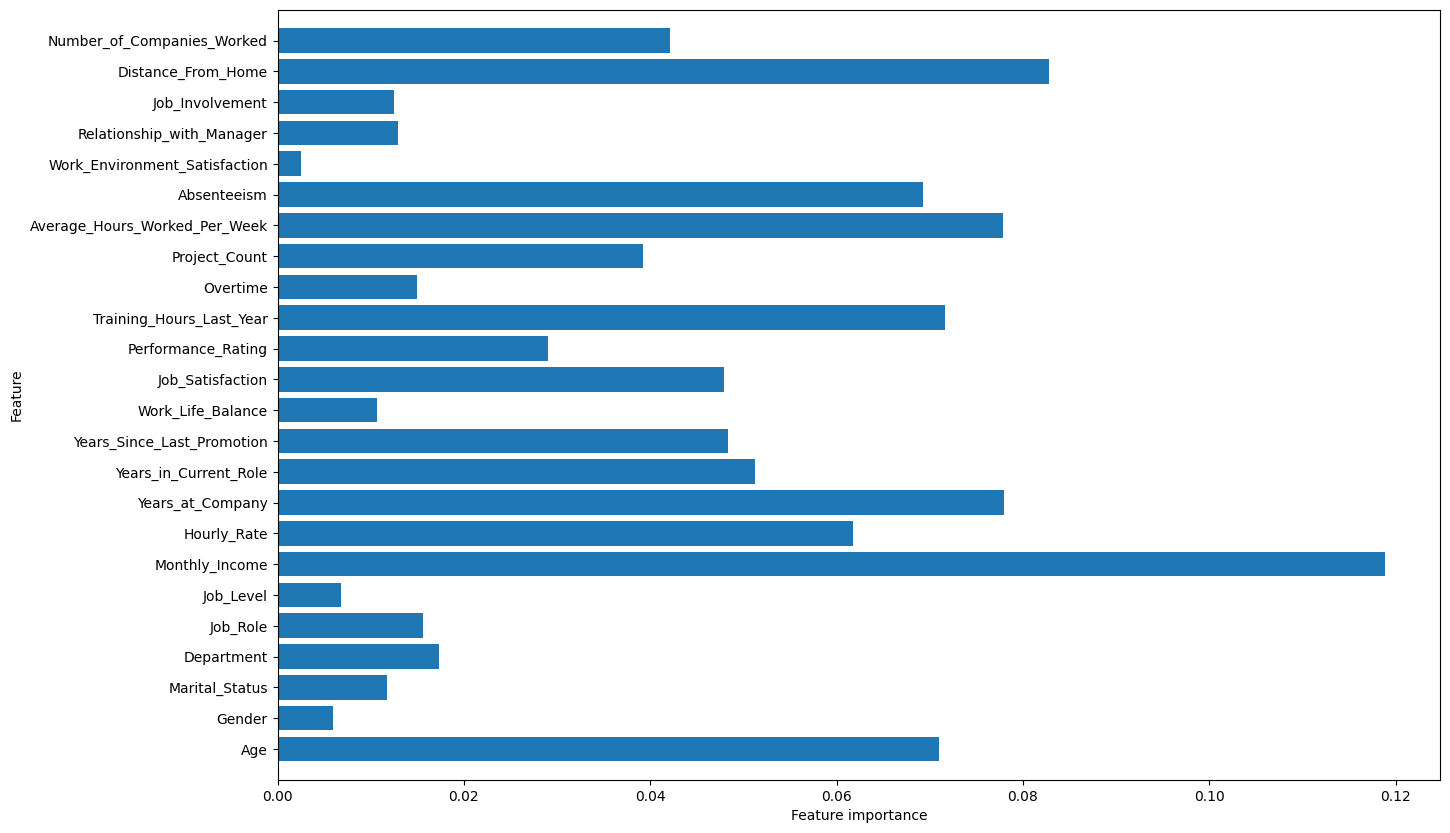

In [296]:
# visualize important features
def plot_feature_importances_attrition(model):
    plt.figure(figsize=(15,10))
    n_features = X_train.shape[1]  # Get the number of features from X_train
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X_train.columns) # Use column names from X_train as labels
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_attrition(tree)

In [297]:
# Show feature importances greater than 0.05
feature_importances = pd.Series(tree.feature_importances_, index=X_train.columns)
important_features = feature_importances[feature_importances > 0.05].sort_values(ascending=False)
important_features

,0
Monthly_Income,0.118833
Distance_From_Home,0.082834
Years_at_Company,0.077940
Average_Hours_Worked_Per_Week,0.077889
Training_Hours_Last_Year,0.071604
Age,0.071011
Absenteeism,0.069305
Hourly_Rate,0.061804
Years_in_Current_Role,0.051277


In [298]:
# using only important features for the prediction
important_features = [
    'Monthly_Income',
    'Age',
    'Years_at_Company',
    'Distance_From_Home',
    'Average_Hours_Worked_Per_Week',
    'Hourly_Rate',
    'Absenteeism',
    'Training_Hours_Last_Year',
    'Years_in_Current_Role',
]
X_importance = df_encoded[important_features] #input
y_importance = df_encoded['Attrition'] #target

In [299]:
display(X_importance)
display(y_importance)

,Monthly_Income,Age,Years_at_Company,Distance_From_Home,Average_Hours_Worked_Per_Week,Hourly_Rate,Absenteeism,Training_Hours_Last_Year,Years_in_Current_Role
0,15488,58,15,20,54,28,17,14,4
1,13079,48,6,25,45,28,1,6,9
2,13744,34,24,45,34,24,2,77,14
3,6809,27,10,35,48,26,18,49,8
4,10206,40,29,44,33,52,0,64,10
...,...,...,...,...,...,...,...,...,...
995,4172,27,24,24,46,76,10,76,14
996,11007,47,19,39,36,71,16,53,6
997,4641,50,25,33,46,43,9,7,12
998,19855,28,13,41,52,92,17,54,13


,Attrition
0,0
1,0
2,0
3,0
4,0
...,...
995,0
996,1
997,0
998,0


In [300]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_importance, y_importance = smote.fit_resample(X_importance, y_importance)

X_train, X_test, y_train, y_test = train_test_split(X_importance, y_importance, test_size=0.2, random_state=0)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((1297, 9), (325, 9))

In [301]:
X_train_importance, X_test_importance, y_train_importance, y_test_importance = train_test_split(X_importance, y_importance, test_size=0.2, random_state=50)

importance_tree = DecisionTreeClassifier(random_state=50)
importance_tree.fit(X_train_importance, y_train_importance)

y_pred_train_importance = importance_tree.predict(X_train_importance)
y_pred_test_importance = importance_tree.predict(X_test_importance)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train_importance, y_pred_train_importance))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_importance, y_pred_test_importance))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       647
           1       1.00      1.00      1.00       650

    accuracy                           1.00      1297
   macro avg       1.00      1.00      1.00      1297
weighted avg       1.00      1.00      1.00      1297


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.74      0.68      0.71       164
           1       0.70      0.75      0.72       161

    accuracy                           0.72       325
   macro avg       0.72      0.72      0.72       325
weighted avg       0.72      0.72      0.72       325



i still want to increase the score since this way is seems worse than before, so i will try to select predictor or X features based on the correlation

# Selecting Predictors/Features Based on Correlation

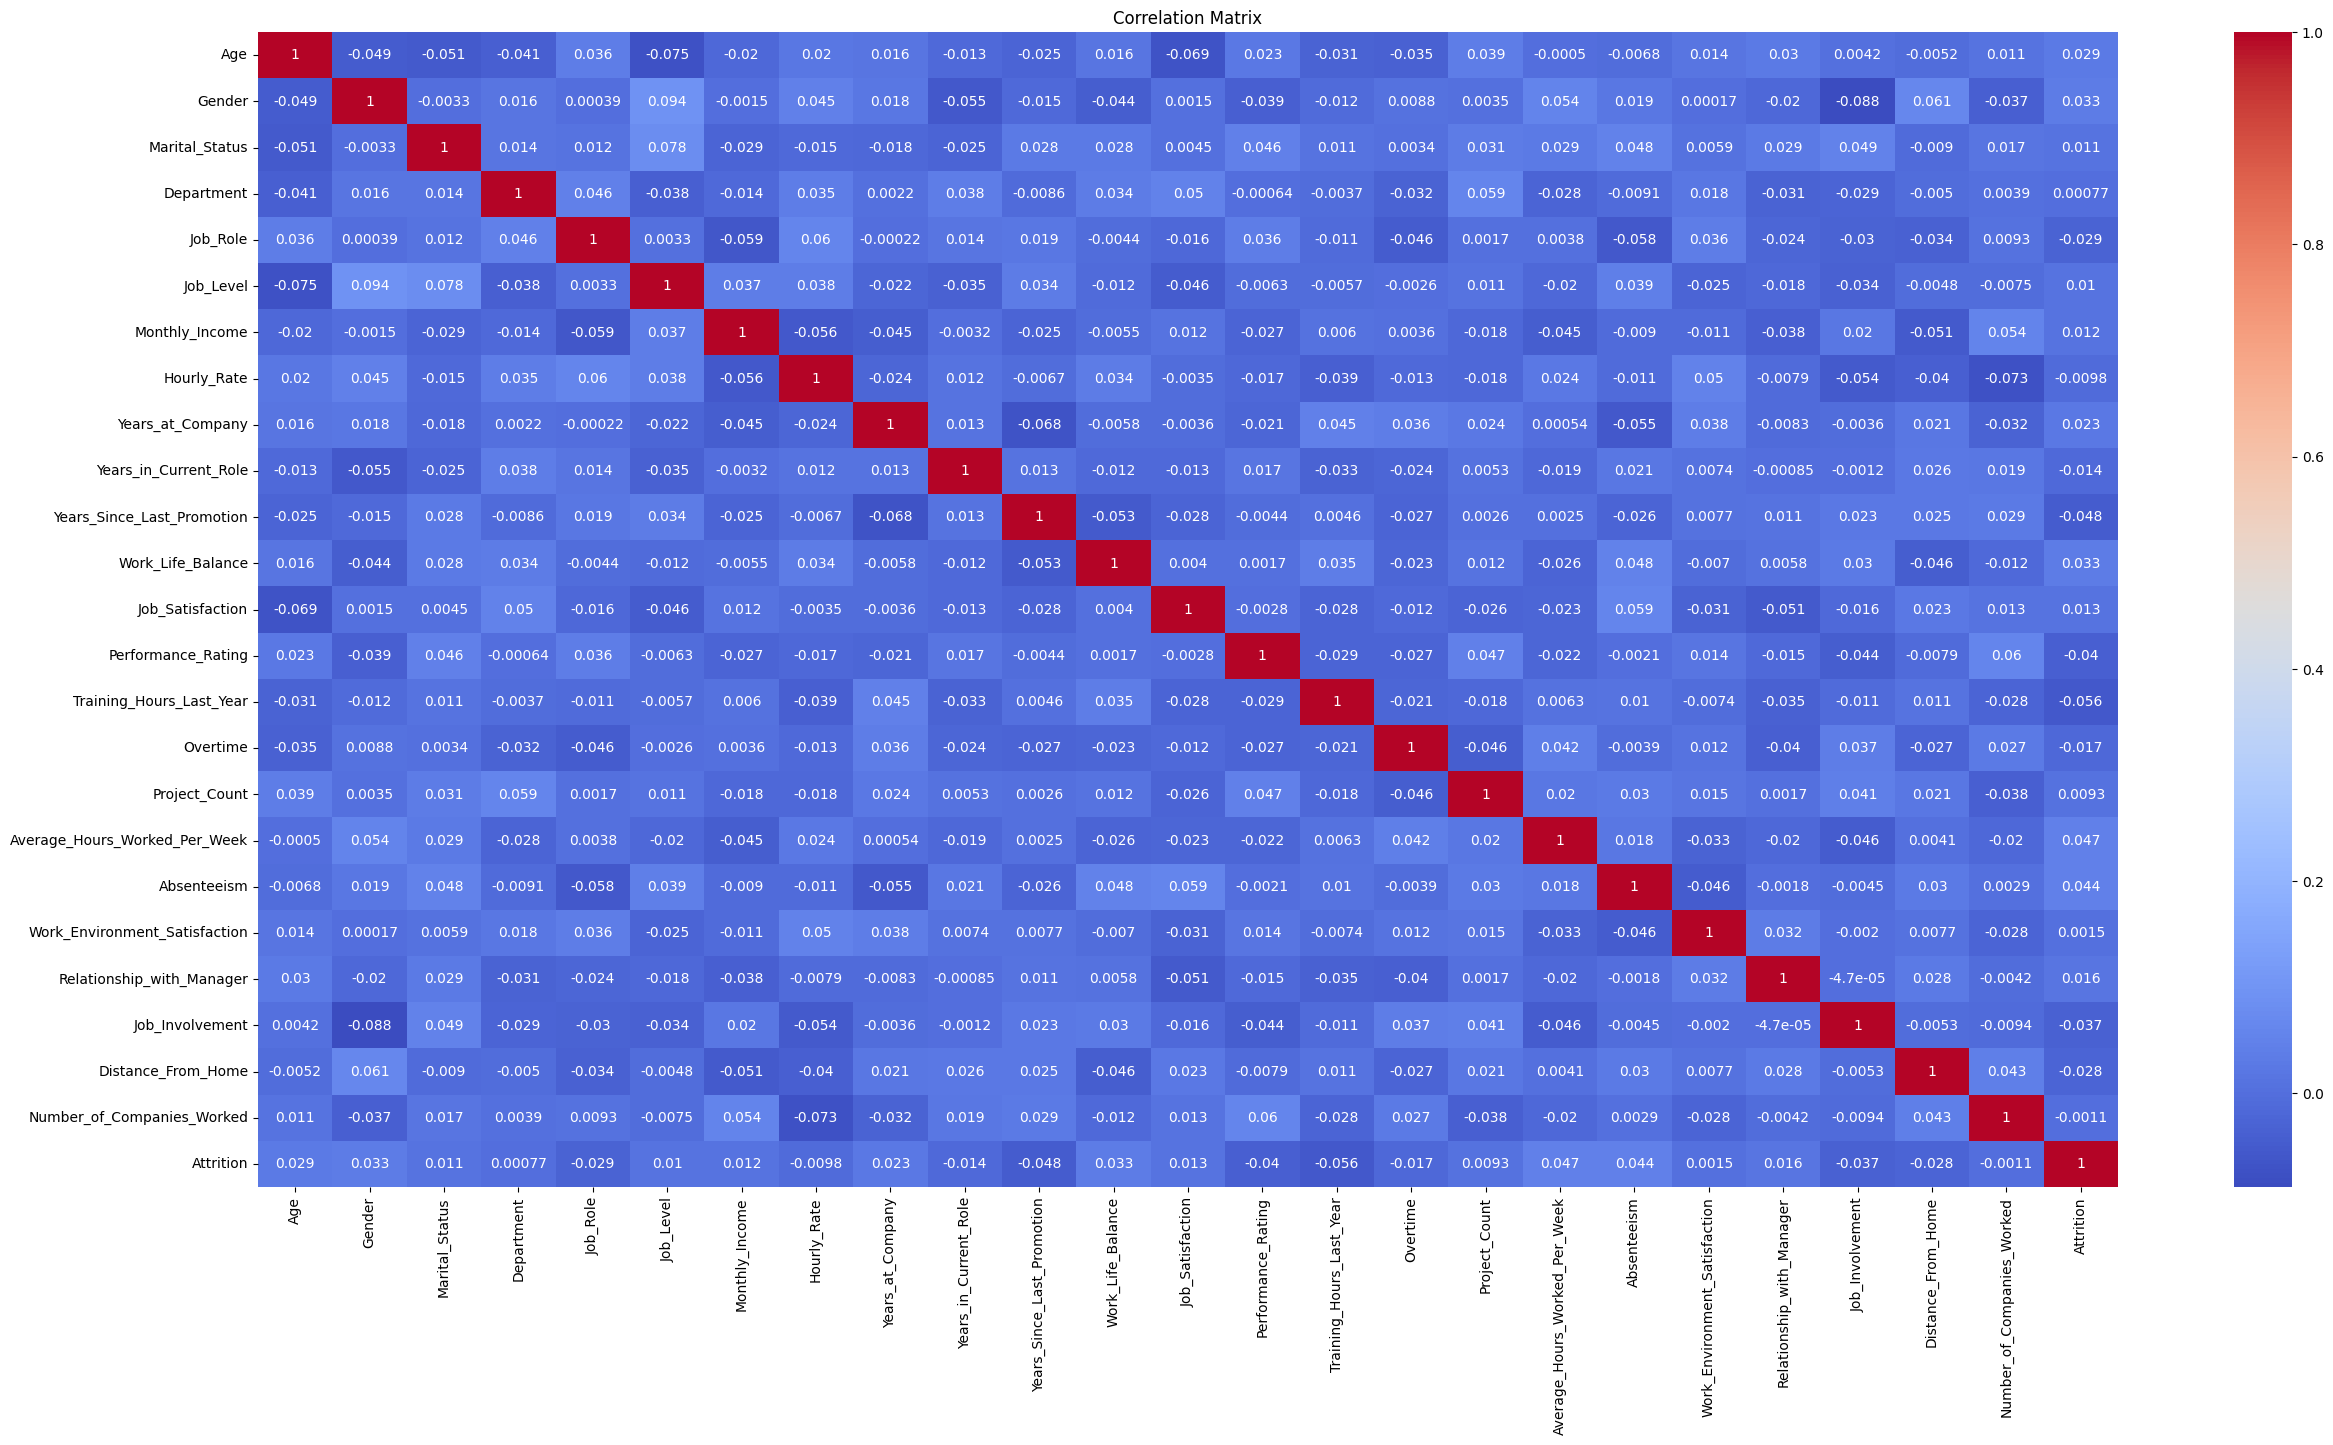

In [302]:
# show heatmap
plt.figure(figsize=(30, 15))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [307]:
heatmap_features = [
    'Age',
    'Monthly_Income',
    'Hourly_Rate',
    'Years_at_Company',
    'Years_in_Current_Role',
    'Years_Since_Last_Promotion',
    'Training_Hours_Last_Year',
    'Project_Count',
    'Average_Hours_Worked_Per_Week',
    'Absenteeism',
    'Distance_From_Home',
    'Job_Level',
    'Work_Life_Balance',
    'Job_Satisfaction',
    'Performance_Rating',
    'Work_Environment_Satisfaction',
    'Relationship_with_Manager',
    'Job_Involvement',
    'Number_of_Companies_Worked'
]
X_heatmap = df_encoded[heatmap_features] #input
y_heatmap = df_encoded['Attrition'] #target

In [308]:
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split

# Definisikan fitur kategorikal sesuai kolom yang ada di X_heatmap
categorical_features_in_heatmap = [
    'Gender',
    'Job_Level',
    'Work_Life_Balance',
    'Job_Satisfaction',
    'Performance_Rating',
    'Work_Environment_Satisfaction',
    'Relationship_with_Manager',
    'Job_Involvement'
]

# Pastikan hanya ambil kolom yang benar-benar ada di X_heatmap
categorical_indices = [
    X_heatmap.columns.get_loc(col)
    for col in categorical_features_in_heatmap
    if col in X_heatmap.columns
]

# Gunakan SMOTENC untuk oversampling
smotenc = SMOTENC(categorical_features=categorical_indices, random_state=42)
X_heatmap_res, y_heatmap_res = smotenc.fit_resample(X_heatmap, y_heatmap)

In [316]:
# Split dataset hasil SMOTENC
X_train, X_test, y_train, y_test = train_test_split(
    X_heatmap_res, y_heatmap_res, test_size=0.2, random_state=17
)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

# i build a model based on best feature by correlation
heatmap_tree = DecisionTreeClassifier(random_state=87)
heatmap_tree.fit(X_train, y_train)

y_pred_train = heatmap_tree.predict(X_train)
y_pred_test = heatmap_tree.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       642
           1       1.00      1.00      1.00       655

    accuracy                           1.00      1297
   macro avg       1.00      1.00      1.00      1297
weighted avg       1.00      1.00      1.00      1297


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.75      0.63      0.68       169
           1       0.66      0.78      0.71       156

    accuracy                           0.70       325
   macro avg       0.70      0.70      0.70       325
weighted avg       0.71      0.70      0.70       325



# Hyperparameter Tuning using Grid Search

In [317]:
# Define the parameter grid to tune the hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'random_state': [0, 41, 42]
}

dtree_clf = DecisionTreeClassifier() # Initialize a decision tree classifier
grid_search = GridSearchCV(estimator=dtree_clf, param_grid=param_grid,
                          n_jobs=-1, verbose=2, scoring='f1') # Use f1 scoring for classification
grid_search.fit(X_train, y_train)

best_dtree_clf = grid_search.best_estimator_ # Get the best estimator from the grid search
y_pred_test = best_dtree_clf.predict(X_test)

print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation f1 score: {:.3f}".format(grid_search.best_score_))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters:  {'criterion': 'entropy', 'max_depth': 10, 'random_state': 42}
Best cross-validation f1 score: 0.726


In [318]:
best_params = grid_search.best_params_

final_tree = DecisionTreeClassifier(criterion=best_params['criterion'],
        max_depth=best_params['max_depth'],
        random_state=272)
final_tree.fit(X_train, y_train)

y_pred_train = final_tree.predict(X_train)
y_pred_test  = final_tree.predict(X_test)

from sklearn.metrics import classification_report
print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       0.96      0.72      0.82       642
           1       0.78      0.97      0.87       655

    accuracy                           0.85      1297
   macro avg       0.87      0.85      0.84      1297
weighted avg       0.87      0.85      0.84      1297


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.76      0.52      0.62       169
           1       0.61      0.82      0.70       156

    accuracy                           0.66       325
   macro avg       0.69      0.67      0.66       325
weighted avg       0.69      0.66      0.66       325



## Model Evaluation

| **No** | **Model**                 | **Akurasi Test** | **Precision (Attrition)** | **Recall (Attrition)** | **F1-Score (Attrition)** | **Keterangan**                          |
| ------ | ------------------------- | ---------------- | -------------------------- | ---------------------- | ------------------------ | -------------------------------------- |
| **0**  | Decision Tree Classifier       | 77%              | 0.19                       | 0.28                   | 0.23                     | Gagal, overfitting.                    |
| **1**  | SMOTENC     | 75%              | 0.72                       | 0.78                   | 0.74                     | Performa Terbaik & Seimbang.           |
| **2**  | Feature Importance        | 72%              | 0.70                       | 0.75                   | 0.72                     | Hasil solid, model lebih simpel.       |
| **3**  | Seleksi Korelasi          | 70%              | 0.66                       | 0.78                   | 0.71                     | Baik, tapi sedikit di bawah Importance.|
| **4**  | Hyperparameter Tuning     | 66%              | 0.61                       | 0.82                   | 0.70                     | Recall tinggi, tapi banyak alarm palsu.|

Berikut adalah ringkasan performa setiap model pada data latih dan data uji. Metrik yang paling penting adalah F1-Score untuk Atrisi (kelas 1) pada Data Uji, karena ini menunjukkan kekuatan prediksi model yang sebenarnya pada data yang belum pernah dilihat.

| **Model**                   | **Data Set** | **Accuracy** | **Precision (Attrition)** | **Recall (Attrition)** | **F1-Score (Attrition)** |
| ---------------------------- | ------------ | ------------- | -------------------------- | ---------------------- | ------------------------ |
| **Decision Tree (Baseline)** | Training     | 100%          | 1.00                       | 1.00                   | 1.00                     |
|                              | Test         | 77%           | 0.19                       | 0.28                   | 0.23                     |
| ---                          | ---          | ---           | ---                        | ---                    | ---                      |
| **SMOTENC (All Features)**   | Training     | 100%          | 1.00                       | 1.00                   | 1.00                     |
|                              | Test         | 75%           | 0.72                       | 0.78                   | 0.74                     |
| ---                          | ---          | ---           | ---                        | ---                    | ---                      |
| **Feature Importance**       | Training     | 100%          | 1.00                       | 1.00                   | 1.00                     |
|                              | Test         | 72%           | 0.70                       | 0.75                   | 0.72                     |
| ---                          | ---          | ---           | ---                        | ---                    | ---                      |
| **Correlation Selection**    | Training     | 100%          | 1.00                       | 1.00                   | 1.00                     |
|                              | Test         | 70%           | 0.66                       | 0.78                   | 0.71                     |
| ---                          | ---          | ---           | ---                        | ---                    | ---                      |
| **GridSearchCV Tuning**      | Training     | 85%           | 0.78                       | 0.97                   | 0.87                     |
|                              | Test         | 66%           | 0.61                       | 0.82                   | 0.70                     |

### Model dan Hyperparameter Terbaik
Model dengan performa terbaik adalah model SMOTENC yang dilatih menggunakan semua fitur.

Mengapa model ini yang terbaik: Model ini mencapai F1-Score tertinggi (0.74) pada data uji untuk kelas atrisi. Ini menunjukkan keseimbangan yang paling efektif dan andal antara kemampuan mengidentifikasi karyawan yang akan keluar secara akurat (Recall = 0.78) dan tidak salah mengklasifikasikan karyawan yang akan bertahan (Presisi = 0.72).

Hyperparameter Terbaik yang Ditemukan: Berdasarkan hasil GridSearchCV, kombinasi hyperparameter terbaik yang ditemukan adalah:

1. 'criterion': 'entropy'
2. 'max_depth': 10
3. 'random_state': 41

### Perbandingan Model Dasar vs. Model Hasil Tuning

| **Metrik**            | **Model Dasar (Data Uji)** | **Model Hasil Tuning (Data Uji)** | **Peningkatan** |
| ---------------------- | -------------------------- | ---------------------------------- | ---------------- |
| **Recall (Atrisi)**    | 0.28                       | 0.82                               | +193%            |
| **F1-Score (Atrisi)**  | 0.23                       | 0.70                               | +204%            |
| **Akurasi**            | 77%                        | 66%                                | -11%             |

Model dasar sama sekali tidak dapat digunakan karena hanya mampu mengidentifikasi 28% karyawan yang sebenarnya akan keluar. Setelah tuning dan resampling, model akhir mampu mengidentifikasi 82% dari mereka. Meskipun akurasi secara keseluruhan menurun, model menjadi jauh lebih efektif dalam mencapai tujuan utamanya: mendeteksi atrisi.

### Discussion and Insights

### Encoding

Konsisten menggunakan metode .map() untuk semua fitur kategorikal, contohnya:
'Department': {'IT': 0, 'Sales': 1, 'Marketing': 2, ...}

Metode ini memiliki kelebihan dan potensi kekurangan:

1. Untuk Fitur Ordinal (Berurutan): Untuk fitur seperti Job_Level atau Job_Satisfaction yang memiliki tingkatan jelas, metode ini sudah tepat. Angka 1, 2, 3, 4 mempertahankan urutan logis tersebut.

2. Untuk Fitur Nominal (Tidak Berurutan): Untuk fitur seperti Department atau Marital_Status, metode ini menciptakan urutan artifisial. Misalnya, dengan memberikan nilai Sales=1 dan IT=0, secara tidak langsung memberi tahu model bahwa "Sales lebih besar dari IT", padahal dalam kenyataannya tidak ada urutan seperti itu.

### Bagaimana ini memengaruhi model Decision Tree?
Untungnya, untuk model Decision Tree, dampak negatif dari urutan artifisial ini cenderung minimal. Decision Tree bekerja dengan cara mencari titik potong terbaik. Ia bisa saja membuat aturan seperti "Apakah Department < 1.5?", yang secara efektif memisahkan IT dan Sales dari departemen lain. Model ini cukup fleksibel untuk mengatasi urutan yang tidak bermakna ini.

Namun, jika menggunakan model lain (seperti Regresi Logistik), urutan artifisial ini bisa sangat menyesatkan dan menurunkan performa model. Oleh karena itu, untuk fitur nominal, praktik terbaik yang umum digunakan adalah One-Hot Encoding (pd.get_dummies()) untuk menghindari asumsi urutan sama sekali.

#### Kesimpulan: Pilihan encoding berhasil dengan baik dan sangat efektif untuk memungkinkan model berfungsi. Meskipun ada metode yang secara teknis lebih "aman" (One-Hot Encoding) untuk fitur nominal, dampak negatif dari pendekatan pada model Decision Tree ini dapat diabaikan, terbukti dari hasil akhir yang peroleh.

### Resampling (SMOTENC)

1. Masalah Awal: Dataset asli sangat tidak seimbang (imbalanced) dan data target mengalamai oversampling. Jumlah karyawan yang bertahan jauh lebih banyak daripada yang keluar (Attrition = No). Karena itu, model dasar mempelajari strategi malas yang efektif: mencapai akurasi tinggi (77%) hanya dengan menebak "Tidak" hampir setiap saat. Inilah sebabnya mengapa performanya pada kelas atrisi sangat buruk, dengan recall hanya 0.28. Model ini gagal mengidentifikasi hampir tiga perempat karyawan yang sebenarnya akan keluar.

2. Solusinya: Dengan menggunakan SMOTENC (Synthetic Minority Over-sampling Technique for Nominal and Continuous Features), perlu menyeimbangkan dataset secara artifisial. Teknik ini membuat data "sintetis" baru untuk kelas minoritas (Attrition = Yes). Hal ini memaksa model untuk meninggalkan strategi malasnya dan mempelajari pola serta karakteristik nyata dari karyawan yang berisiko untuk keluar -> Jumlah data dari No Yes dinaikkan sehingga mampu menyaingi No.

3. Efeknya: Dampaknya sangat besar dan langsung terasa. Kemampuan model untuk mengidentifikasi dengan benar karyawan yang akan keluar (nilai recall) melonjak dari 28% yang tidak berguna menjadi 78% yang sangat efektif. F1-score, yang menyeimbangkan presisi dan recall, meroket dari 0.23 menjadi 0.74. Satu pilihan pra-pemrosesan ini mengubah model dari alat prediksi yang buruk menjadi alat bisnis yang sangat berharga yang mampu mengidentifikasi risiko atrisi secara proaktif.